### Bibliotecas utilizadas

In [181]:
import pandas as pd
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate

### Abertura de CSV

In [182]:
df = pd.read_excel("Dados_Temperatura.xlsx")

temperatura = df['Temperatura (K)']
altura = df['Elevação (km)']

print(df)

    Elevação (km)  Temperatura (K)
0               0       301.301604
1               1       278.240837
2               2       277.521503
3               3       260.259064
4               4       275.382433
5               5       252.070363
6               6       259.201939
7               7       248.331449
8               8       227.136951
9               9       226.493083
10             10       217.689877
11             11       216.650000


### Declarando constantes

In [183]:
R = 287.058 # J/Kg*K
T = -56.5 + 273.15 # K -> Será utilizada no caso 1
G = 9.81 # m/s²
p_0 = 101325 # Pa

### Caso 2: Temperatura variante

Para o intervalo de 0 até 11,0 km, onde a temperatura varia, utilizando os 
dados de temperatura em anexo, ajustar uma função T(E) utilizando o 
cálculo matricial do Método dos Mínimos Quadrados (MMQ, OLS em inglês). 
Após a obtenção da função de T(E), obter a função p(E), plotar o gráfico
 de Pressão X Elevação (pressão na ordenada).

$T(E) = aE + b$

$a$: temperatura no nível do mar

$b$: variação da temperatura

Será resolvido pelo cálculo das matrizes

$[Y] = [X] \cdot [\beta]$

$Y$: valores da temperatura

$X$: valores da elevação

$\beta$: matriz com coeficientes a,b

Nosso objetivo é achar $\beta$, então podemos fazer $[\beta] = [X]^{-1} * [Y]$

In [184]:
Y = temperatura.to_numpy().reshape(-1,1)
print('Matriz Y')
print(Y)

print("\n------------------------------")

X = altura.to_numpy().reshape(-1,1) * 1000 # Converte para metros
coluna_1 = np.ones((Y.shape[0], 1))
X = np.hstack((coluna_1, X))

print('Matrix X')
print(X)

print("\n------------------------------")

# Pseudo inversa de Penrose
def penrose(X, Y):
    return np.linalg.inv(X.T @ X) @ X.T @ Y

beta = penrose(X, Y)

a = beta[1] # Temperatura no nível do mar
b = beta[0] # Variação de temperatura

print(f"Coeficientes: a = {a}, b = {b}")

Matriz Y
[[301.30160387]
 [278.24083745]
 [277.52150309]
 [260.25906395]
 [275.38243282]
 [252.07036337]
 [259.20193877]
 [248.33144933]
 [227.13695085]
 [226.49308318]
 [217.68987674]
 [216.65      ]]

------------------------------
Matrix X
[[1.0e+00 0.0e+00]
 [1.0e+00 1.0e+03]
 [1.0e+00 2.0e+03]
 [1.0e+00 3.0e+03]
 [1.0e+00 4.0e+03]
 [1.0e+00 5.0e+03]
 [1.0e+00 6.0e+03]
 [1.0e+00 7.0e+03]
 [1.0e+00 8.0e+03]
 [1.0e+00 9.0e+03]
 [1.0e+00 1.0e+04]
 [1.0e+00 1.1e+04]]

------------------------------
Coeficientes: a = [-0.0072481], b = [293.22115289]


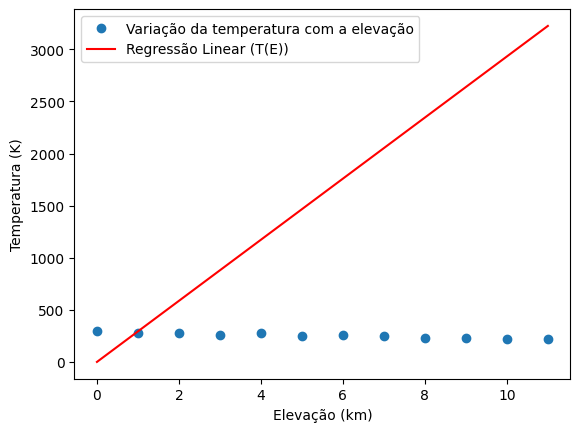

In [ ]:
def t(e):
    return a + b*e

plt.plot(Y, 'o', label='Variação da temperatura com a elevação')
plt.plot(altura, t(altura), 'r', label='Regressão Linear (T(E))')
plt.xlabel("Elevação (km)")
plt.ylabel("Temperatura (K)")
plt.legend()
plt.show()

## Resolução

$$ \frac{dp}{dz} = -ρg $$

Onde:

$$
\begin{aligned}
ρ = \frac{p}{R T}
\end{aligned}
$$

Então:

$$ \frac{dp}{dz} = \frac{-pg}{RT} $$
$$\int^{p}_{p_0} \frac{dP}{p} = -\frac{g}{R} \int^{z}_{z_0} \frac{dz}{T}$$
$$\int^{p}_{p_0} \frac{dP}{p}  = -\frac{g}{R} \int^{z}_{z_0} \frac{dz}{(az+b)}$$

$$\frac{ln(p)}{ln(p_0)} = -\frac{g}{aR} \cdot \frac{ln(az+b)}{ln(b)} $$

$$ {ln(p)} = {ln(p_o)} \cdot \frac{g}{aR}\cdot \frac{ln(az+b)}{ln(b)} $$

$$ {(e)} \cdot  {ln(p)} = {ln(p_o)} \cdot \frac{g}{aR}\cdot \frac{ln(az+b)}{ln(b)} \cdot {(e)}$$

$$ {p} = {p_o} \cdot {(e)^{\frac{g}{aR} \cdot \frac{ln(az+b)}{ln(b)} }}$$

$$
p = p_o \cdot e^{\left( \frac{\ln(az + b)}{\ln(b)} \right)^{\frac{g}{aR}}} $$

$$
p = p_o \cdot \left( \frac{az + b}{b} \right)^{\frac{g}{aR}}$$

**Portanto a função P(E) é:**

$$
p(E) = p_o \cdot \left( \frac{T(E)}{(b)} \right)^{\frac{g}{aR}}$$

In [190]:
def p(e):
    return p_0 * ((a*e+b)/b)**(-(G/(R*a)))

p_11 = p(11000)

p_11

array([22695.26669017])